In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix, recall_score, precision_score, f1_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.exceptions import ConvergenceWarning
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
import torch
import torch.nn as nn
import torch.optim as optim
import time
import warnings


In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
data_df = pd.read_csv('E:\\PythonCertificates\\Network Anaomoly detection\\networkanomalydataset.csv')
data_df.head()

,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
0,0.931000,1.224246,0.931001,1.224244,0
1,0.965773,1.302733,0.965944,1.303585,0
2,1.018103,1.341763,1.017932,1.342183,0
3,1.088629,1.374144,1.088671,1.374348,0
4,1.128772,1.381435,1.128727,1.380781,0


In [4]:
data_df.describe()

,Inbound Rate(bit/s),Outbound Rate(bit/s),Inbound Bandwidth Utilization(%),Outbound Bandwidth Utilization(%),Label
count,1.654000e+03,1.654000e+03,1.654000e+03,1.654000e+03,1654.000000
mean,1.374690e-16,-1.374690e-16,-6.873448e-17,2.062035e-16,0.500000
std,1.000302e+00,1.000302e+00,1.000302e+00,1.000302e+00,0.500151
min,-8.587873e-01,-8.451589e-01,-8.587677e-01,-8.450422e-01,0.000000
25%,-8.071507e-01,-8.063695e-01,-8.072172e-01,-8.064441e-01,0.000000
50%,-7.555341e-01,-7.747574e-01,-7.554490e-01,-7.751713e-01,0.500000
75%,9.628647e-01,1.112895e+00,9.627478e-01,1.112738e+00,1.000000
max,2.122913e+00,1.997753e+00,2.122901e+00,1.998350e+00,1.000000


In [5]:
data_df.shape

(1654, 5)

In [6]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1654 entries, 0 to 1653
Data columns (total 5 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Inbound Rate(bit/s)                1654 non-null   float64
 1   Outbound Rate(bit/s)               1654 non-null   float64
 2   Inbound Bandwidth Utilization(%)   1654 non-null   float64
 3   Outbound Bandwidth Utilization(%)  1654 non-null   float64
 4   Label                              1654 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 64.7 KB


In [7]:
data_df.isnull().sum()

Inbound Rate(bit/s)                  0
Outbound Rate(bit/s)                 0
Inbound Bandwidth Utilization(%)     0
Outbound Bandwidth Utilization(%)    0
Label                                0
dtype: int64

In [8]:
print(data_df['Inbound Rate(bit/s)'].describe())
print(data_df['Outbound Rate(bit/s)'].describe())
print(data_df['Inbound Bandwidth Utilization(%)'].describe())
print(data_df['Outbound Bandwidth Utilization(%)'].describe())

count    1.654000e+03
mean     1.374690e-16
std      1.000302e+00
min     -8.587873e-01
25%     -8.071507e-01
50%     -7.555341e-01
75%      9.628647e-01
max      2.122913e+00
Name: Inbound Rate(bit/s), dtype: float64
count    1.654000e+03
mean    -1.374690e-16
std      1.000302e+00
min     -8.451589e-01
25%     -8.063695e-01
50%     -7.747574e-01
75%      1.112895e+00
max      1.997753e+00
Name: Outbound Rate(bit/s), dtype: float64
count    1.654000e+03
mean    -6.873448e-17
std      1.000302e+00
min     -8.587677e-01
25%     -8.072172e-01
50%     -7.554490e-01
75%      9.627478e-01
max      2.122901e+00
Name: Inbound Bandwidth Utilization(%), dtype: float64
count    1.654000e+03
mean     2.062035e-16
std      1.000302e+00
min     -8.450422e-01
25%     -8.064441e-01
50%     -7.751713e-01
75%      1.112738e+00
max      1.998350e+00
Name: Outbound Bandwidth Utilization(%), dtype: float64


In [9]:
data_df.rename(columns={'Inbound Rate(bit/s)':'Inbound_Rate','Outbound Rate(bit/s)':'Outbound_Rate',
                        'Inbound Bandwidth Utilization(%)':'Inbound_Bandwidth_Utilization',
                        'Outbound Bandwidth Utilization(%)':'Outbound_Bandwidth_Utilization'}, inplace=True)
data_df.head()

,Inbound_Rate,Outbound_Rate,Inbound_Bandwidth_Utilization,Outbound_Bandwidth_Utilization,Label
0,0.931000,1.224246,0.931001,1.224244,0
1,0.965773,1.302733,0.965944,1.303585,0
2,1.018103,1.341763,1.017932,1.342183,0
3,1.088629,1.374144,1.088671,1.374348,0
4,1.128772,1.381435,1.128727,1.380781,0


Label
0    827
1    827
Name: count, dtype: int64


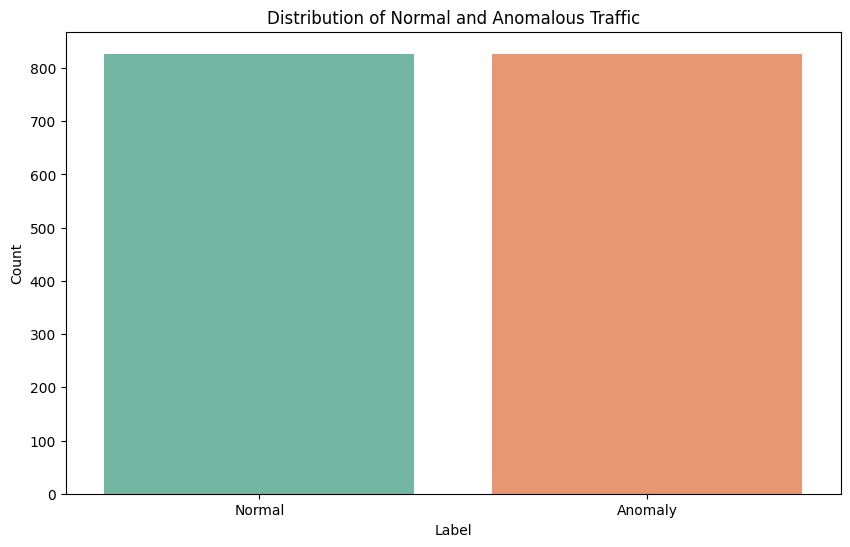

In [10]:
print(data_df['Label'].value_counts())
plt.figure(figsize=(10, 6))
sns.countplot(data=data_df,x='Label', hue='Label',palette='Set2', legend=False)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Normal and Anomalous Traffic')
plt.xticks([0, 1], ['Normal', 'Anomaly'])

plt.show()

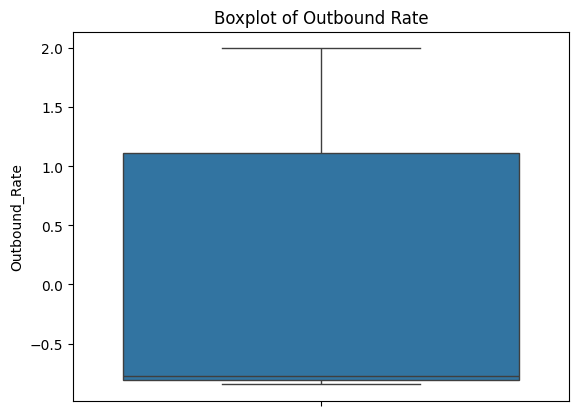

In [11]:
plt.Figure(figsize=(12,8))
sns.boxplot(data=data_df, y='Outbound_Rate')
plt.title('Boxplot of Outbound Rate')
plt.show()

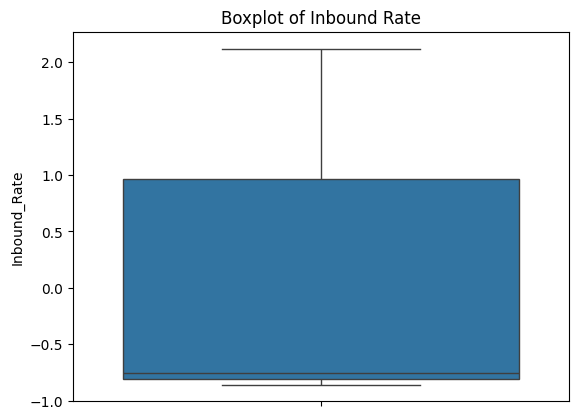

In [12]:
plt.Figure(figsize=(12,8))
sns.boxplot(data=data_df, y='Inbound_Rate')
plt.title('Boxplot of Inbound Rate')
plt.show()

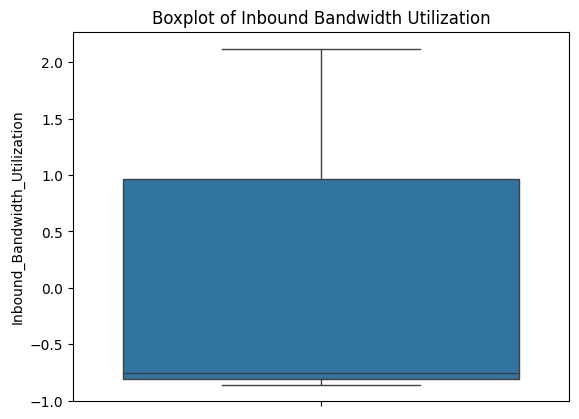

In [13]:
plt.Figure(figsize=(12,8))
sns.boxplot(data=data_df, y='Inbound_Bandwidth_Utilization')
plt.title('Boxplot of Inbound Bandwidth Utilization')
plt.show()

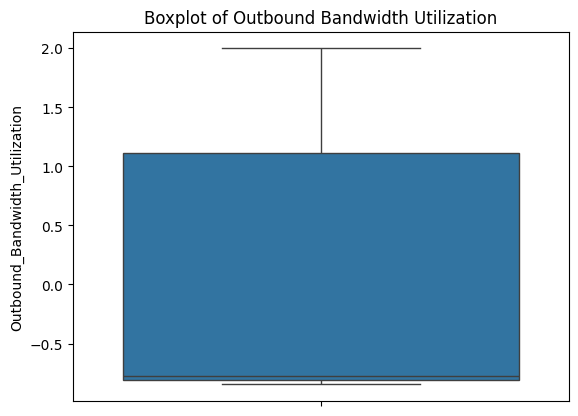

In [14]:
plt.Figure(figsize=(12,8))
sns.boxplot(data=data_df, y='Outbound_Bandwidth_Utilization')
plt.title('Boxplot of Outbound Bandwidth Utilization')
plt.show()

## Preprocessing

In [15]:
X = data_df.drop('Label', axis=1)
y = data_df['Label']

print(X.head())
print(y.head())

   Inbound_Rate  Outbound_Rate  Inbound_Bandwidth_Utilization  \
0      0.931000       1.224246                       0.931001   
1      0.965773       1.302733                       0.965944   
2      1.018103       1.341763                       1.017932   
3      1.088629       1.374144                       1.088671   
4      1.128772       1.381435                       1.128727   

   Outbound_Bandwidth_Utilization  
0                        1.224244  
1                        1.303585  
2                        1.342183  
3                        1.374348  
4                        1.380781  
0    0
1    0
2    0
3    0
4    0
Name: Label, dtype: int64


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.35,random_state=42,stratify=y)

In [17]:
augmentation_factor = 6
noise_factor = 0.02

X_augmented_list = []
y_augmented_list = []

for i in range(augmentation_factor):
    noise = np.random.normal(
        loc=0,
        scale=X_train.std() * noise_factor,
        size=X_train.shape
    )
    X_synthetic = X_train + noise
    X_augmented_list.append(X_synthetic)
    y_augmented_list.append(y_train.copy())

X_augmented = pd.concat(X_augmented_list, ignore_index=True)
y_augmented = pd.concat(y_augmented_list, ignore_index=True)

X_train_final = pd.concat([X_train, X_augmented],ignore_index=True)
y_train_final = pd.concat([y_train, y_augmented],ignore_index=True)

print("Original Training Size:", X_train.shape)
print("Final Training Size:", X_train_final.shape)

Original Training Size: (1075, 4)
Final Training Size: (7525, 4)


In [18]:
lr_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
]) 

In [19]:
knn_preprocessor = Pipeline([
    ('scaler', StandardScaler()),
])

In [20]:
svm_preprocessor = Pipeline([
    ('scaler', StandardScaler()),
])


Modelling and Training

In [21]:
lr_pipeline = Pipeline(steps=[('preprocessor', lr_preprocessor),
                              ('model', LogisticRegression(random_state=42))])


--- Training Completed ---
Time taken to run the model grid search: 3.66 seconds
Best Hyperparameters for Logistic Regression: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       290
           1       0.96      1.00      0.98       289

    accuracy                           0.98       579
   macro avg       0.98      0.98      0.98       579
weighted avg       0.98      0.98      0.98       579

Recall Score: 1.0
Accuracy Score: 0.9792746113989638
Precision Score: 0.9601328903654485
F1 Score: 0.9796610169491525


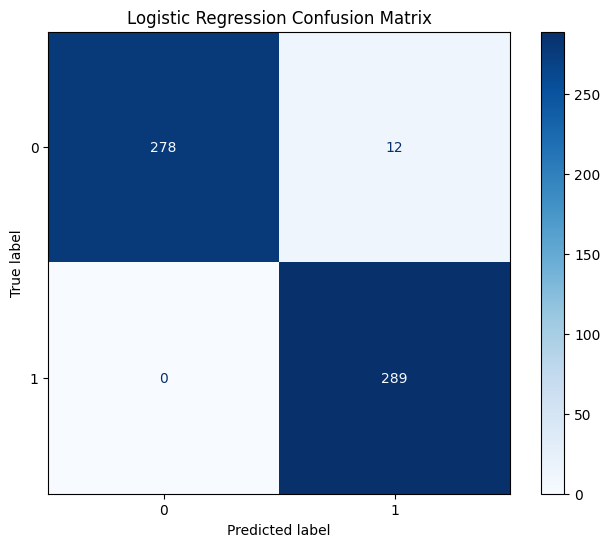

In [22]:


lr_params = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear'],
    'model__penalty': ['l1', 'l2']
}

lr_grid = GridSearchCV(estimator=lr_pipeline, param_grid=lr_params, cv=5, scoring='f1')

start_time = time.time()
lr_grid.fit(X_train_final, y_train_final)
end_time = time.time()
execution_time = end_time - start_time
print("\n--- Training Completed ---")
print(f"Time taken to run the model grid search: {execution_time:.2f} seconds")
print("Best Hyperparameters for Logistic Regression:", lr_grid.best_params_)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Recall Score:", recall_score(y_test, y_pred_lr))
print("Accuracy Score:", accuracy_score(y_test, y_pred_lr))
print("Precision Score:", precision_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

fig, ax = plt.subplots(figsize=(8, 6))
confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_lr, 
    cmap=plt.cm.Blues, 
    ax=ax
)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


K nearest Neighbour

In [23]:
knn_pipeline = Pipeline(steps=[('preprocessor', knn_preprocessor),
                               ('model', KNeighborsClassifier())])


--- Training Completed ---
Time taken to run the model grid search: 3.23 seconds

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       290
           1       0.96      1.00      0.98       289

    accuracy                           0.98       579
   macro avg       0.98      0.98      0.98       579
weighted avg       0.98      0.98      0.98       579

Recall Score: 1.0
Accuracy Score: 0.9792746113989638
Precision Score: 0.9601328903654485
F1 Score: 0.9796610169491525


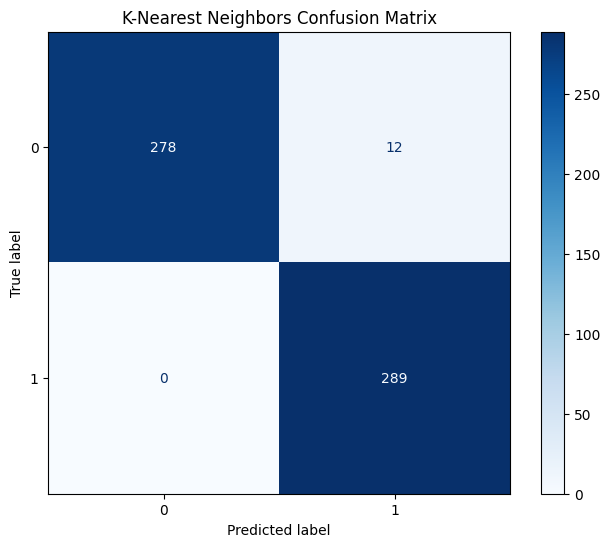

In [24]:
knn_paramgrid = {
    'model__n_neighbors':[3,5,7,9,11,13,15,17,19,20],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(estimator=knn_pipeline, param_grid=knn_paramgrid, cv=5, scoring='f1')

start_time = time.time()
knn_grid.fit(X_train_final, y_train_final)
end_time = time.time()
execution_time = end_time - start_time
print("\n--- Training Completed ---")
print(f"Time taken to run the model grid search: {execution_time:.2f} seconds")

best_knn = knn_grid.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("\nK-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("Recall Score:", recall_score(y_test, y_pred_knn))
print("Accuracy Score:", accuracy_score(y_test, y_pred_knn))
print("Precision Score:", precision_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

fig, ax = plt.subplots(figsize=(8, 6))
confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_knn, 
    cmap=plt.cm.Blues, 
    ax=ax
)
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.show()


SVM model

In [25]:
svc_pipeline = Pipeline(steps=[('preprocessor', svm_preprocessor),
                               ('model', SVC(random_state=42))])


--- Training Completed ---
Time taken to run the model grid search: 8.07 seconds

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       290
           1       0.95      1.00      0.98       289

    accuracy                           0.98       579
   macro avg       0.98      0.98      0.98       579
weighted avg       0.98      0.98      0.98       579

Recall Score: 1.0
Accuracy Score: 0.9758203799654577
Precision Score: 0.9537953795379538
F1 Score: 0.9763513513513513


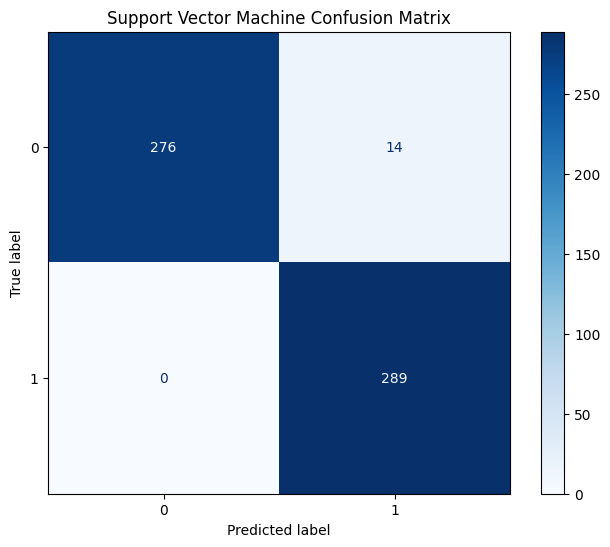

In [26]:
svc_paramgrid = {
    'model__C':[0.01,0.1,1,10,100],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

svc_grid = GridSearchCV(estimator=svc_pipeline, param_grid=svc_paramgrid, cv=5, scoring='f1')

start_time = time.time()
svc_grid.fit(X_train_final, y_train_final)
end_time = time.time()
execution_time = end_time - start_time
print("\n--- Training Completed ---")
print(f"Time taken to run the model grid search: {execution_time:.2f} seconds")

best_svc = svc_grid.best_estimator_
y_pred_svc = best_svc.predict(X_test)

print("\nSupport Vector Machine Classification Report:")
print(classification_report(y_test, y_pred_svc))
print("Recall Score:", recall_score(y_test, y_pred_svc))
print("Accuracy Score:", accuracy_score(y_test, y_pred_svc))
print("Precision Score:", precision_score(y_test, y_pred_svc))
print("F1 Score:", f1_score(y_test, y_pred_svc))

fig, ax = plt.subplots(figsize=(8, 6))
confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_svc, 
    cmap=plt.cm.Blues, 
    ax=ax
)
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

Decision Tree

In [27]:
decision_tree_pipeline = Pipeline(steps=[('model', DecisionTreeClassifier(random_state=42))])


--- Training Completed ---
Time taken to run the model grid search: 7.55 seconds

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       290
           1       0.96      1.00      0.98       289

    accuracy                           0.98       579
   macro avg       0.98      0.98      0.98       579
weighted avg       0.98      0.98      0.98       579

Recall Score: 1.0
Accuracy Score: 0.9775474956822107
Precision Score: 0.956953642384106
F1 Score: 0.9780033840947546


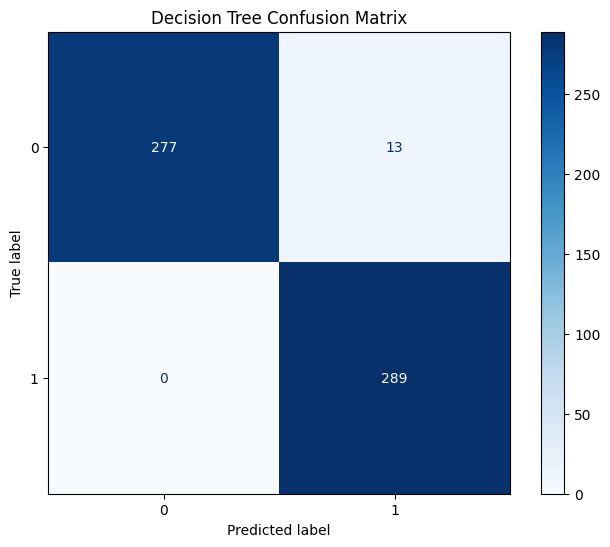

In [28]:
decision_tree_paramgrid = {
    'model__max_depth': [3, 5, 10, 20, 30, 40],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__criterion': ['gini', 'entropy']}

decision_tree_grid = GridSearchCV(estimator=decision_tree_pipeline, param_grid=decision_tree_paramgrid, cv=5, scoring='f1')
start_time = time.time()
decision_tree_grid.fit(X_train_final, y_train_final)
end_time = time.time()
execution_time = end_time - start_time
print("\n--- Training Completed ---")
print(f"Time taken to run the model grid search: {execution_time:.2f} seconds")
best_decision_tree = decision_tree_grid.best_estimator_
y_pred_decision_tree = best_decision_tree.predict(X_test)
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_decision_tree))
print("Recall Score:", recall_score(y_test, y_pred_decision_tree))
print("Accuracy Score:", accuracy_score(y_test, y_pred_decision_tree))
print("Precision Score:", precision_score(y_test, y_pred_decision_tree))
print("F1 Score:", f1_score(y_test, y_pred_decision_tree))
fig, ax = plt.subplots(figsize=(8, 6))
confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_decision_tree, 
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Decision Tree Confusion Matrix")
plt.show()

Random Forest pipeline

In [29]:
randomforest_pipeline = Pipeline(steps=[('model', RandomForestClassifier(random_state=42))])


--- Training Completed ---
Time taken to run the model grid search: 510.55 seconds

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       290
           1       0.96      1.00      0.98       289

    accuracy                           0.98       579
   macro avg       0.98      0.98      0.98       579
weighted avg       0.98      0.98      0.98       579

Recall Score: 1.0
Accuracy Score: 0.9810017271157168
Precision Score: 0.9633333333333334
F1 Score: 0.9813242784380306


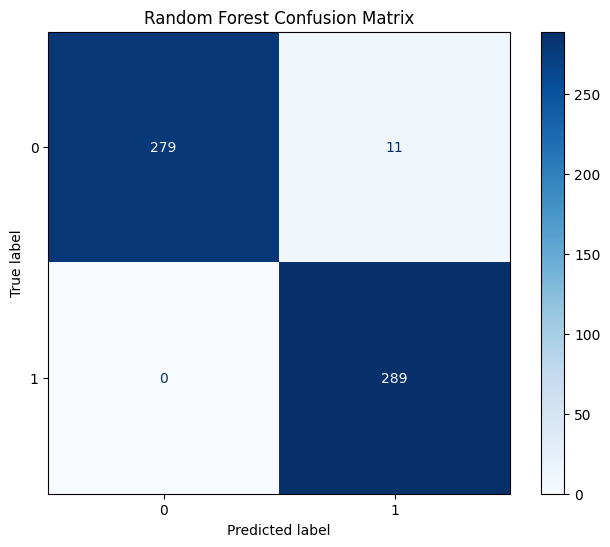

In [30]:
randomforest_paramgrid = {
    'model__n_estimators': [100,200,300],
    'model__max_depth': [3, 5, 10,20,30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

randomforest_grid = GridSearchCV(estimator=randomforest_pipeline, param_grid=randomforest_paramgrid, cv=5, scoring='f1')
start_time = time.time()
randomforest_grid.fit(X_train_final, y_train_final)
end_time = time.time()
execution_time = end_time - start_time
print("\n--- Training Completed ---")
print(f"Time taken to run the model grid search: {execution_time:.2f} seconds")
best_randomforest = randomforest_grid.best_estimator_
y_pred_randomforest = best_randomforest.predict(X_test)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_randomforest))
print("Recall Score:", recall_score(y_test, y_pred_randomforest))
print("Accuracy Score:", accuracy_score(y_test, y_pred_randomforest))
print("Precision Score:", precision_score(y_test, y_pred_randomforest))
print("F1 Score:", f1_score(y_test, y_pred_randomforest))
fig, ax = plt.subplots(figsize=(8, 6))
confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_randomforest, 
    cmap=plt.cm.Blues, 
    ax=ax
)
plt.title("Random Forest Confusion Matrix")
plt.show()

XGBOOST

In [31]:
xgb_pipeline = Pipeline([
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])


--- Training Completed ---
Time taken to run the model grid search: 6.02 seconds
Best Hyperparameters for XGBoost: {'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 200}

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       290
           1       0.96      1.00      0.98       289

    accuracy                           0.98       579
   macro avg       0.98      0.98      0.98       579
weighted avg       0.98      0.98      0.98       579

Recall Score: 1.0
Accuracy Score: 0.9810017271157168
Precision Score: 0.9633333333333334
F1 Score: 0.9813242784380306


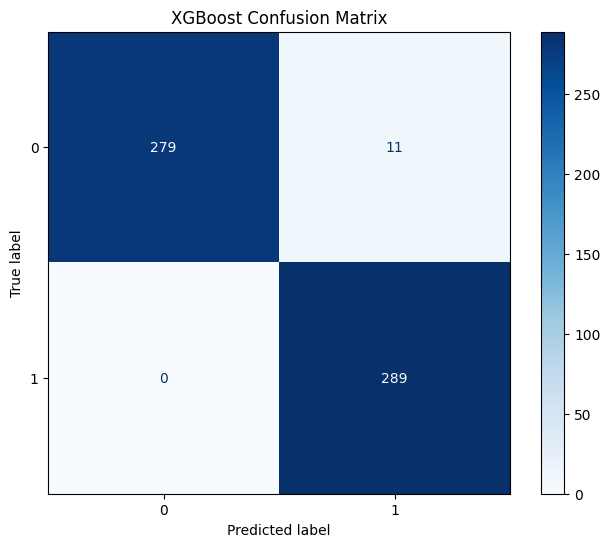

In [32]:
xgb_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1]
}

xgb_grid = GridSearchCV(estimator=xgb_pipeline, param_grid=xgb_params, cv=5, scoring='f1')
start_time = time.time()
xgb_grid.fit(X_train_final, y_train_final)
end_time = time.time()
execution_time = end_time - start_time
print("\n--- Training Completed ---")
print(f"Time taken to run the model grid search: {execution_time:.2f} seconds")
print("Best Hyperparameters for XGBoost:", xgb_grid.best_params_)
best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("Recall Score:", recall_score(y_test, y_pred_xgb))
print("Accuracy Score:", accuracy_score(y_test, y_pred_xgb))
print("Precision Score:", precision_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
fig, ax = plt.subplots(figsize=(8, 6))
confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_xgb, 
    cmap=plt.cm.Blues, 
    ax=ax
)
plt.title("XGBoost Confusion Matrix")
plt.show()

Neural Network

In [33]:
def standardizationfornetural(x_train, y_train, x_test, y_test):
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    X_train_tensor = torch.tensor(
        x_train_scaled,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        x_test_scaled,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train.values,
        dtype=torch.float32
    ).view(-1, 1)

    y_test_tensor = torch.tensor(
        y_test.values,
        dtype=torch.float32
    ).view(-1, 1)
    return X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor

In [34]:
X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor = standardizationfornetural(X_train_final, y_train_final, X_test, y_test)

In [35]:
class NetworkAnomalyNN(nn.Module):

    def __init__(self):

        super(NetworkAnomalyNN, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(4, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(12, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        return self.model(x)

In [36]:
model = NetworkAnomalyNN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [37]:
epochs = 1000
epochsarray = []
lossarray = []
for epoch in range(epochs):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )
    epochsarray.append(epoch + 1)
    lossarray.append(loss.item())

Epoch [10/1000], Loss: 0.6495
Epoch [20/1000], Loss: 0.6054
Epoch [30/1000], Loss: 0.5679
Epoch [40/1000], Loss: 0.5387
Epoch [50/1000], Loss: 0.5176
Epoch [60/1000], Loss: 0.4950
Epoch [70/1000], Loss: 0.4734
Epoch [80/1000], Loss: 0.4547
Epoch [90/1000], Loss: 0.4346
Epoch [100/1000], Loss: 0.4166
Epoch [110/1000], Loss: 0.3982
Epoch [120/1000], Loss: 0.3835
Epoch [130/1000], Loss: 0.3668
Epoch [140/1000], Loss: 0.3494
Epoch [150/1000], Loss: 0.3359
Epoch [160/1000], Loss: 0.3246
Epoch [170/1000], Loss: 0.3127
Epoch [180/1000], Loss: 0.2986
Epoch [190/1000], Loss: 0.2912
Epoch [200/1000], Loss: 0.2769
Epoch [210/1000], Loss: 0.2681
Epoch [220/1000], Loss: 0.2619
Epoch [230/1000], Loss: 0.2534
Epoch [240/1000], Loss: 0.2472
Epoch [250/1000], Loss: 0.2390
Epoch [260/1000], Loss: 0.2318
Epoch [270/1000], Loss: 0.2246
Epoch [280/1000], Loss: 0.2168
Epoch [290/1000], Loss: 0.2150
Epoch [300/1000], Loss: 0.2089
Epoch [310/1000], Loss: 0.2035
Epoch [320/1000], Loss: 0.1982
Epoch [330/1000],

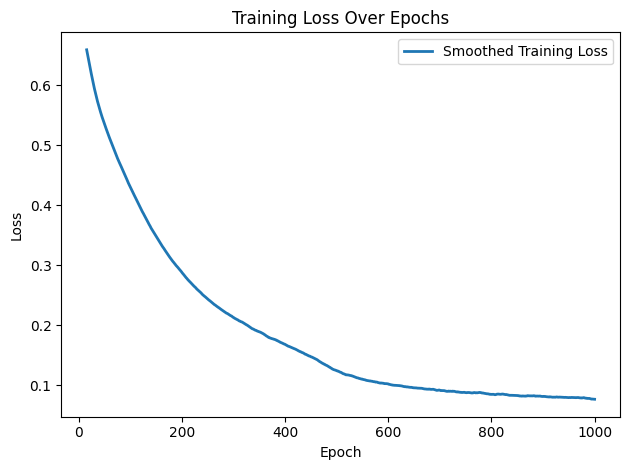

In [38]:
window_size = 15
smoothed_loss = np.convolve(lossarray, np.ones(window_size)/window_size, mode='valid')
smoothed_epochs = epochsarray[window_size - 1:]
plt.plot(smoothed_epochs, smoothed_loss, label='Smoothed Training Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.tight_layout()
plt.savefig('smooth_loss.png')

In [39]:
with torch.no_grad():
    predictions = model(X_test_tensor)
    predicted_classes = (
        predictions >= 0.5
    ).float()


              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98       290
         1.0       0.96      1.00      0.98       289

    accuracy                           0.98       579
   macro avg       0.98      0.98      0.98       579
weighted avg       0.98      0.98      0.98       579

Recall Score: 1.0
Accuracy Score: 0.9792746113989638
Precision Score: 0.9601328903654485
F1 Score: 0.9796610169491525


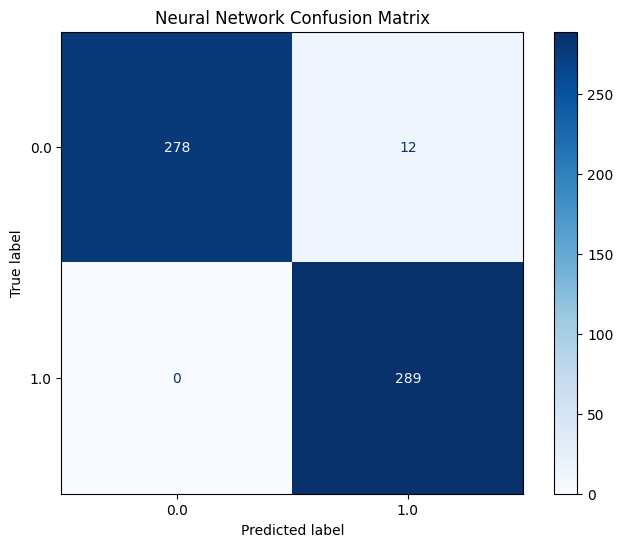

In [40]:
print(
    classification_report(
        y_test_tensor,
        predicted_classes
    )
)

print("Recall Score:", recall_score(y_test_tensor, predicted_classes))
print("Accuracy Score:", accuracy_score(y_test_tensor, predicted_classes))
print("Precision Score:", precision_score(y_test_tensor, predicted_classes))
print("F1 Score:", f1_score(y_test_tensor, predicted_classes))
fig, ax = plt.subplots(figsize=(8, 6))
confusion_matrix_display = ConfusionMatrixDisplay.from_predictions(
    y_test_tensor,
    predicted_classes,
    cmap=plt.cm.Blues,
    ax=ax
)
plt.title("Neural Network Confusion Matrix")
plt.show()